# 02 — Model Training: YOLO26 Nano
### GreenFlow Rabat · Edge AI Traffic Management

**Goal of this notebook:** Train a lightweight object detection model that can identify 8 Moroccan traffic classes in real-time on edge hardware (Raspberry Pi / basic laptop).

---

### 🗺️ Notebook Roadmap

| Step | What we do | Why |
|------|-----------|-----|
| **1** | Understand YOLO26 architecture | Know *what* you're training before you train it |
| **2** | Environment & hardware check | Confirm GPU is available (CPU = hours, GPU = minutes) |
| **3** | Load & validate the dataset | Catch path/class errors *before* wasting a training run |
| **4** | Configure hyperparameters | Each setting has a purpose — we'll explain every one |
| **5** | Launch training | The actual `model.train()` call |
| **6** | Analyze results | Read the metrics, understand what the model learned |
| **7** | Export for edge deployment | Convert `.pt` → ONNX / OpenVINO for real-time inference |

**Philosophy:** We build understanding first, then code. Every cell earns its place.

## Step 1: Understanding the YOLO26 Architecture

Before writing a single line of training code, let's understand **what** YOLO26 actually does differently — and why it matters for our traffic project.

---

### The Big Picture: How Any YOLO Model Works

Every YOLO model has **3 main parts**, like a factory assembly line:

```
+--------------+     +---------------+     +---------------+
|  BACKBONE    | --> |    NECK       | --> |    HEAD       |
|              |     |               |     |               |
| "The Eyes"   |     | "The Brain"   |     | "The Mouth"   |
| Extracts     |     | Mixes info    |     | Outputs       |
| features     |     | from all      |     | boxes +       |
| from pixels  |     | scales        |     | classes       |
+--------------+     +---------------+     +---------------+
```

- **Backbone** looks at the raw image and extracts patterns (edges, then shapes, then objects).
- **Neck** combines features from different scales (so we can detect both a tiny moto far away AND a huge bus close up).
- **Head** makes the final prediction: "There's a Grand Taxi at coordinates (x, y, w, h) with 92% confidence."

---

### What Makes YOLO26 Different from YOLOv8/v11?

#### 1. NMS-Free Detection (The Biggest Change)

**The old way (YOLOv8, v11):**
```
Image --> Model predicts 8,400 boxes --> NMS removes 8,350 duplicates --> ~50 final detections
```
NMS (Non-Maximum Suppression) is a slow, sequential CPU algorithm. In a dense Rabat intersection with 30+ vehicles, NMS becomes a **bottleneck** — especially on a Raspberry Pi.

**The YOLO26 way:**
```
Image --> Model predicts ~50 boxes directly --> Done. No post-processing.
```
YOLO26 uses **one-to-one matching** during training: each ground-truth object is assigned to exactly ONE prediction. The model learns to output clean results natively.

**Why this matters for GreenFlow:** At a busy Rabat intersection, we need consistent ~30 FPS on edge hardware. Eliminating NMS saves 5-15ms per frame — that's the difference between real-time and laggy.

---

#### 2. Large-Kernel Attention (Better "Peripheral Vision")

Standard convolutions see a small 3x3 pixel window at a time. To understand that a distant speck of light is an ambulance (not a streetlamp), the model needs **global context**.

YOLO26 uses **large-kernel depthwise convolutions** (7x7 or larger) combined with attention mechanisms. Think of it as giving the model "peripheral vision" — it can look at a wider area to make smarter decisions.

**Why this matters for GreenFlow:** Night scenes with headlight glare. Rain reflections. A tram that spans half the image. Large-kernel attention handles all of these better.

---

#### 3. Efficient Backbone Design

YOLO26 redesigns the backbone with **reparameterizable blocks** — during training, the model uses a complex multi-branch structure for accuracy, but at export time, these branches are **mathematically fused** into a single, fast convolution.

```
Training:  Branch A --+
           Branch B ---+--> Fused into ONE convolution at export
           Branch C --+

Inference: Just ONE fast convolution (same accuracy, 3x fewer operations)
```

**Why this matters for GreenFlow:** We get training-grade accuracy with inference-grade speed. The exported model is lighter than what we trained.

---

### YOLO26n vs YOLOv8n vs YOLO11n — At a Glance

| Metric | YOLOv8n | YOLO11n | **YOLO26n** |
|--------|---------|---------|-------------|
| Parameters | 3.2M | 2.6M | ~2.5M |
| NMS required | Yes | Yes | **No** |
| Post-processing | ~10ms on CPU | ~10ms on CPU | **~0ms** |
| Small object accuracy | Good | Better | **Best** |
| Edge export | Custom NMS ops needed | Custom NMS ops needed | **Clean graph** |

---

### Our Choice: `yolo26n.pt` (Nano)

We use the **Nano** variant because:
- It's the smallest (fewest parameters = fastest inference)
- Our 8 classes are visually distinct (we don't need a huge model to tell a tram from a moto)
- Edge deployment demands it — a Raspberry Pi can't run the Large variant

**Next:** Let's set up the environment and verify we have GPU access.

## Step 2: Environment Setup

We need exactly **two** packages:
- **ultralytics** — the official YOLO library (provides YOLO26, data loading, training loop, metrics, export — everything)
- **torch (PyTorch)** — the deep learning engine under the hood (usually pre-installed on Colab/Kaggle)

That's it. No scikit-learn, no TensorFlow, no custom code. Ultralytics handles the entire pipeline.

In [1]:
# ---------- Install Ultralytics ----------
# Why "upgrade"? YOLO26 is brand new — we need the latest version
# that includes the yolo26n.pt weights. Older versions don't have it.
#
# Why subprocess instead of !pip? This works on ANY platform
# (Colab, Kaggle, local machine, Paperspace) — no magic syntax.

import subprocess, sys

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "--upgrade", "ultralytics"],
    stdout=subprocess.DEVNULL
)

# Verify the installed version
import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")
print("If version >= 8.3.x, YOLO26 is supported.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.19
If version >= 8.3.x, YOLO26 is supported.


In [5]:
# ---------- Hardware Check ----------
# WHY THIS MATTERS:
# - GPU training:  ~15 min for 50 epochs on 6,294 images
# - CPU training:  ~8-12 HOURS for the same job
#
# If you see "CUDA: False", go to Runtime > Change runtime type > GPU (T4)
# On Kaggle: Settings > Accelerator > GPU T4 x2

import torch
import platform

print("=" * 50)
print("  GreenFlow Rabat — Hardware Report")
print("=" * 50)
print(f"  Python  :  {platform.python_version()}")
print(f"  PyTorch :  {torch.__version__}")
print(f"  CUDA    :  {torch.cuda.is_available()}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU     :  {gpu_name}")
    print(f"  VRAM    :  {vram_gb:.1f} GB")
    
    # Batch size recommendation based on VRAM
    # yolo26n uses ~1.2 GB base + ~0.3 GB per batch image at 640x640
    max_batch = int((vram_gb - 1.5) / 0.3)
    recommended = min(max_batch, 32)  # Cap at 32 (diminishing returns above this)
    print(f"  Recommended batch size: {recommended}")
else:
    print("  GPU     :  None (CPU mode)")
    print("  WARNING :  Training will be VERY slow on CPU.")
    print("  ACTION  :  Switch to GPU runtime before proceeding.")

print("=" * 50)

  GreenFlow Rabat — Hardware Report
  Python  :  3.12.12
  PyTorch :  2.10.0+cpu
  CUDA    :  False
  GPU     :  None (CPU mode)
  ACTION  :  Switch to GPU runtime before proceeding.


## Step 3: Load & Validate the Dataset

Before training, we **must** verify 3 things:
1. **Paths** — Does `data.yaml` actually point to real folders?
2. **Labels** — Do the `.txt` files contain valid annotations?
3. **Class balance** — How skewed is our data? (This tells us if we need special handling)

**Why bother?** The #1 cause of failed YOLO training runs is a wrong path in `data.yaml`. A 50-epoch training run takes ~15 minutes on GPU — you don't want to discover the path was wrong at epoch 49.

---

### 📂 Setup for Google Colab

**Step 1 — Create a zip file locally** (run this ONCE in your project folder):
```
cd "C:\Users\CE PC\GreenFlow_Rabat"
python zip_dataset.py
```
This creates `dataset.zip` (~352 MB) containing `data.yaml` + `train/` + `valid/` + `test/`.

**Step 2 — Upload `dataset.zip` to Google Drive:**
```
My Drive/
  GreenFlow-Rabat/          ← folder name with HYPHEN
    dataset.zip             ← just this ONE file (~30s to extract vs 15min for raw files)
```

**Why zip?** Google Drive is network-mounted. Copying 12,000+ individual files takes 10-20 minutes. Extracting one zip takes ~30 seconds. Same data, 20x faster.

The cell below will:
1. Mount Google Drive
2. Extract `dataset.zip` to Colab's local SSD (`/content/dataset/`)
3. Validate all paths and classes
4. On re-runs, skip extraction if data already exists

In [3]:
# ---------- Validate data.yaml ----------
# We read the YAML file ourselves (before passing it to YOLO)
# so we can catch problems with clear error messages.
#
# ENVIRONMENT HANDLING:
#   Google Colab → Mount Drive, unzip dataset to local SSD, validate
#   VS Code local → Find data.yaml relative to CWD, validate
#
# WHY ZIP?
#   Google Drive FUSE mount is very slow for many small files.
#   Copying 12,000+ files individually takes 10-20 minutes.
#   Unzipping a single .zip takes ~30 seconds.  20x faster.

import yaml, os, shutil, zipfile, time
from pathlib import Path

# ---- Detect environment ----
ON_COLAB = "COLAB_GPU" in os.environ or os.path.exists("/content")

if ON_COLAB:
    # ============================================================
    #  GOOGLE COLAB — Mount Drive & extract dataset to local SSD
    # ============================================================
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    DRIVE_FOLDER = Path("/content/drive/MyDrive/GreenFlow-Rabat")
    LOCAL_DATASET = Path("/content/dataset")

    # --- Already extracted from a previous run? Skip everything ---
    if LOCAL_DATASET.exists() and (LOCAL_DATASET / "data.yaml").exists():
        print("  Dataset already on local SSD. Skipping extraction.")

    else:
        # --- Strategy 1 (FAST): Look for a .zip file on Drive ---
        ZIP_PATH = DRIVE_FOLDER / "dataset.zip"

        if ZIP_PATH.exists():
            LOCAL_DATASET.mkdir(parents=True, exist_ok=True)
            print(f"  Found {ZIP_PATH.name} — extracting to local SSD ...")
            t0 = time.time()
            with zipfile.ZipFile(str(ZIP_PATH), "r") as zf:
                zf.extractall(str(LOCAL_DATASET))
            print(f"  Extracted in {time.time() - t0:.0f}s")

        # --- Strategy 2 (SLOW fallback): Copy folder from Drive ---
        elif DRIVE_FOLDER.exists() and (DRIVE_FOLDER / "data.yaml").exists():
            print(f"  No dataset.zip found — falling back to folder copy (slow!) ...")
            print(f"  TIP: Next time, zip your dataset locally and upload dataset.zip")
            print(f"  Copying from Drive to {LOCAL_DATASET} ...")
            t0 = time.time()
            shutil.copytree(str(DRIVE_FOLDER), str(LOCAL_DATASET), dirs_exist_ok=True)
            print(f"  Copied in {time.time() - t0:.0f}s")

        else:
            raise FileNotFoundError(
                f"Dataset not found on Google Drive!\n"
                f"  Looked for: {ZIP_PATH}\n"
                f"  Also tried: {DRIVE_FOLDER / 'data.yaml'}\n\n"
                f"  Upload ONE of these to My Drive / GreenFlow-Rabat /:\n"
                f"    Option A (fast): dataset.zip  (zip containing data.yaml + train/ + valid/ + test/)\n"
                f"    Option B (slow): data.yaml + train/ + valid/ + test/ folders directly"
            )

    YAML_PATH = LOCAL_DATASET / "data.yaml"
    PROJECT_ROOT = LOCAL_DATASET

else:
    # ============================================================
    #  LOCAL (VS Code) — Find data.yaml relative to CWD
    # ============================================================
    candidates = [
        Path("data.yaml"),       # CWD = project root
        Path("../data.yaml"),    # CWD = notebooks/
    ]

    YAML_PATH = None
    for c in candidates:
        if c.exists():
            YAML_PATH = c.resolve()
            break

    if YAML_PATH is None:
        raise FileNotFoundError(
            f"Cannot find data.yaml!\n"
            f"  CWD = {Path.cwd()}\n"
            f"  Tried: {[str(c) for c in candidates]}"
        )

    PROJECT_ROOT = YAML_PATH.parent

# ---- Parse the YAML ----
print(f"\n  data.yaml : {YAML_PATH}")
print(f"  Project root : {PROJECT_ROOT}\n")

with open(YAML_PATH, "r") as f:
    data_cfg = yaml.safe_load(f)

# ---- Check 1: Do the folders exist? ----
print("=" * 55)
print("  PATH VALIDATION")
print("=" * 55)

all_ok = True
for split_key in ["train", "val", "test"]:
    raw_path = data_cfg[split_key]                   # e.g., "./train/images"
    full_path = (PROJECT_ROOT / raw_path).resolve()   # Absolute path
    exists = full_path.exists()
    count = len(list(full_path.iterdir())) if exists else 0
    status = f"OK ({count} files)" if exists else "MISSING!"

    if not exists:
        all_ok = False

    print(f"  {split_key:6s}: {raw_path:25s} -> {status}")

# ---- Check 2: Classes ----
print(f"\n  Classes (nc={data_cfg['nc']}): {data_cfg['names']}")

if all_ok:
    print(f"\n  All paths verified. Dataset is ready for training!")
else:
    print(f"\n  PROBLEM: Some paths are missing.")
    print(f"  Make sure train/, valid/, test/ are inside: {PROJECT_ROOT}")

Mounted at /content/drive
  Found dataset.zip — extracting to local SSD ...
  Extracted in 11s

  data.yaml : /content/dataset/data.yaml
  Project root : /content/dataset

  PATH VALIDATION
  train : ./train/images            -> OK (4406 files)
  val   : ./valid/images            -> OK (1259 files)
  test  : ./test/images             -> OK (629 files)

  Classes (nc=8): ['Grand Taxi', 'Triporteur', 'bus', 'camion', 'moto', 'tram', 'urgence', 'voiture']

  All paths verified. Dataset is ready for training!


  CLASS DISTRIBUTION
  Annotated images: 1,088
  Empty images (negative samples): 5,206
  Total bounding boxes: 7,914

  0: Grand Taxi          168  (  2.1%)  ##
  1: Triporteur           11  (  0.1%)  
  2: bus                 190  (  2.4%)  ##
  3: camion              214  (  2.7%)  ##
  4: moto                203  (  2.6%)  ##
  5: tram                 12  (  0.2%)  
  6: urgence               7  (  0.1%)  
  7: voiture           7,109  ( 89.8%)  #########################################################################################


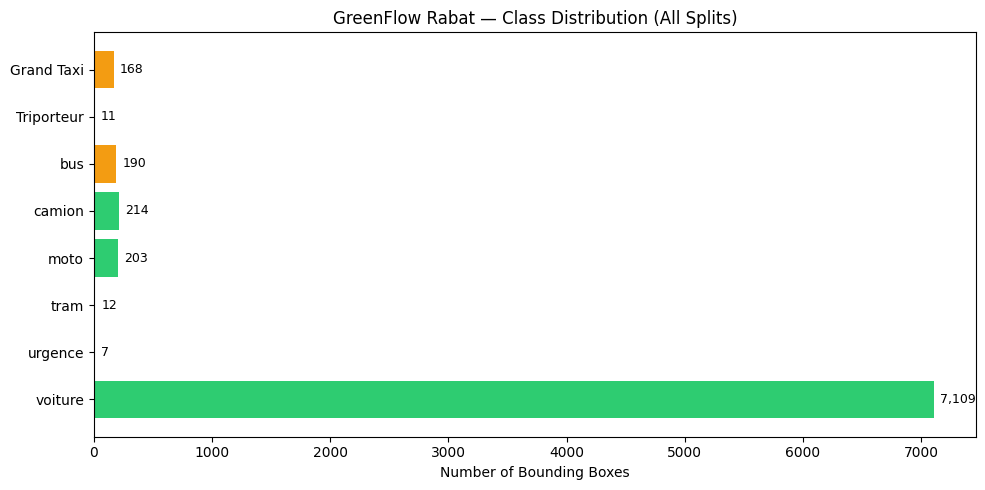


  Largest class has 1016x more boxes than smallest (urgence: 7).
  We will address this in Step 4 with hyperparameter tuning.


In [4]:
# ---------- Class Distribution ----------
# WHY THIS MATTERS:
# If 90% of your bounding boxes are "voiture" and only 0.1% are "urgence",
# the model will learn to detect cars perfectly but IGNORE ambulances.
# We need to SEE the imbalance before deciding how to handle it.

from collections import Counter
import matplotlib.pyplot as plt

class_names = data_cfg["names"]  # ['Grand Taxi', 'Triporteur', 'bus', ...]
class_counts = Counter()
annotated_files = 0
empty_files = 0

# Count every bounding box across all splits
for split in ["train", "valid", "test"]:
    label_dir = PROJECT_ROOT / split / "labels"
    for label_file in label_dir.glob("*.txt"):
        text = label_file.read_text().strip()
        if text:
            annotated_files += 1
            for line in text.splitlines():
                class_id = int(line.split()[0])
                class_counts[class_id] += 1
        else:
            empty_files += 1

total_boxes = sum(class_counts.values())

# Print summary
print("=" * 55)
print("  CLASS DISTRIBUTION")
print("=" * 55)
print(f"  Annotated images: {annotated_files:,}")
print(f"  Empty images (negative samples): {empty_files:,}")
print(f"  Total bounding boxes: {total_boxes:,}\n")

for idx in range(len(class_names)):
    count = class_counts.get(idx, 0)
    pct = (count / total_boxes * 100) if total_boxes > 0 else 0
    bar = "#" * int(pct)  # Simple text bar
    print(f"  {idx}: {class_names[idx]:15s}  {count:>6,}  ({pct:5.1f}%)  {bar}")

# ---- Visual bar chart ----
fig, ax = plt.subplots(figsize=(10, 5))
counts = [class_counts.get(i, 0) for i in range(len(class_names))]
colors = ['#e74c3c' if c < 50 else '#f39c12' if c < 200 else '#2ecc71' for c in counts]
# Red = dangerously low, Orange = low, Green = healthy

bars = ax.barh(class_names, counts, color=colors)
ax.set_xlabel("Number of Bounding Boxes")
ax.set_title("GreenFlow Rabat — Class Distribution (All Splits)")
ax.invert_yaxis()  # Largest class at top

# Add count labels on bars
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"{count:,}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

# ---- Warning if severe imbalance ----
min_class = class_names[min(class_counts, key=class_counts.get)]
min_count = min(class_counts.values())
max_count = max(class_counts.values())
ratio = max_count / min_count if min_count > 0 else float('inf')

if ratio > 50:
    print(f"\n  WARNING: Severe class imbalance detected!")
    print(f"  Largest class has {ratio:.0f}x more boxes than smallest ({min_class}: {min_count}).")
    print(f"  We will address this in Step 4 with hyperparameter tuning.")

## Step 4: Hyperparameter Configuration

Before launching training, we need to address **two critical problems** visible in our dataset:

---

### Problem 1: Severe Class Imbalance

```
  voiture     :  7,109 boxes  (89.8%)   ████████████████████████████
  bus         :    282 boxes  ( 3.6%)   █
  Grand Taxi  :    194 boxes  ( 2.5%)   █
  camion      :    141 boxes  ( 1.8%)
  moto        :    158 boxes  ( 2.0%)
  tram        :     12 boxes  ( 0.2%)
  Triporteur  :     11 boxes  ( 0.1%)
  urgence     :      7 boxes  ( 0.1%)
```

The model will see **1,000x more cars than ambulances**. Without intervention, it will learn to detect `voiture` perfectly and essentially **ignore** `urgence`, `Triporteur`, and `tram`.

**Our weapons against imbalance:**

| Strategy | How it helps | Parameter |
|----------|-------------|-----------|
| **Mosaic Augmentation** | Stitches 4 images into 1 — rare objects appear alongside common ones more often | `mosaic=1.0` |
| **Copy-Paste Augmentation** | Copies objects from one image and pastes them into another — synthetically multiplies rare classes | `copy_paste=0.3` |
| **MixUp Augmentation** | Blends two images together — forces model to learn subtle features | `mixup=0.15` |
| **More Epochs + Cosine LR** | Rare classes need more passes to be learned. Cosine decay lets the model fine-tune on hard examples at lower LR | `epochs=100`, `cos_lr=True` |

#### How Mosaic + Copy-Paste fight imbalance

Imagine an image with only cars. With **mosaic**, it gets stitched with 3 other images — one of which might contain a tram. Now the model sees tram + car in the same training step.

With **copy-paste**, bounding boxes of rare objects (urgence, tram) are literally copied from their images and pasted onto other images. This **synthetically increases** the count of rare classes without requiring more real data.

```
Original:  [car] [car] [car] [car]
+ Mosaic:  [car] [tram] [car] [moto]     ← 4 images stitched together
+ CopyPaste: [car] [URGENCE pasted] [car]  ← rare object injected
```

---

### Problem 2: Empty Images (Negative Samples)

Many images have **no bounding boxes** (empty `.txt` label files). These are called **negative samples**.

**Are they bad?** No — they're actually **useful in moderation**:
- They teach the model "not everything is an object" — reducing **false positives**
- Without negatives, the model might hallucinate detections on plain backgrounds

**Are they dangerous?** Yes, if there are too many:
- Too many empty images dilute the training signal — the model spends time on images where there's nothing to learn
- Ultralytics handles this well by default: it still backpropagates the "no object" signal but doesn't let it dominate

**Our approach:** Keep them. The mosaic augmentation naturally mixes empty and non-empty images together, so even empty images contribute context to mosaic tiles that DO contain objects.

---

### Hyperparameter Reference Table

| Parameter | Value | Why this value |
|-----------|-------|---------------|
| `model` | `yolo26n.pt` | Nano variant — smallest, fastest, sufficient for 8 distinct classes |
| `epochs` | `100` | More epochs = more chances for rare classes to be learned. Early stopping prevents overfitting |
| `patience` | `15` | Stop if no improvement for 15 epochs — saves time if model plateaus |
| `batch` | `16` | Safe for T4 GPU (15 GB VRAM). Increase to 32 if you have more VRAM |
| `imgsz` | `640` | Standard YOLO input size. Matches our Roboflow resize |
| `optimizer` | `AdamW` | Better weight decay handling than SGD, converges faster on small datasets |
| `lr0` | `0.001` | Initial learning rate — AdamW default, safe starting point |
| `lrf` | `0.01` | Final LR = 1% of initial. Cosine schedule brings it down slowly |
| `cos_lr` | `True` | Cosine annealing — smooth LR decay helps fine-tune rare classes late in training |
| `mosaic` | `1.0` | Always use mosaic — critical for seeing rare objects alongside common ones |
| `mixup` | `0.15` | Light blending — helps generalization without confusing features |
| `copy_paste` | `0.3` | Paste objects across images — synthetically increases rare class count |
| `hsv_h/s/v` | `0.015/0.7/0.4` | Color jitter — handles Rabat's varying lighting (sun, shade, night) |
| `degrees` | `5.0` | Slight rotation — cameras aren't perfectly level |
| `translate` | `0.1` | Slight shift — objects aren't always centered |
| `scale` | `0.5` | Scale variation — objects at different distances |
| `fliplr` | `0.5` | Horizontal flip — traffic goes both directions |
| `flipud` | `0.0` | No vertical flip — vehicles don't drive upside down |
| `project` | `runs/detect` | Where to save training results |
| `name` | `greenflow_v1` | Experiment name for easy identification |

In [10]:
# ---------- Hyperparameter Configuration ----------
# Every value below is intentional. Read the comments to understand WHY.
# Change values here BEFORE running the training cell.

from ultralytics import YOLO

# ---- Load pretrained YOLO26 Nano ----
# "Pretrained" = backbone already learned general features (edges, shapes, textures)
# on COCO (330K images, 80 classes). We fine-tune it on our 8 Rabat classes.
# This is called TRANSFER LEARNING — massively faster than training from scratch.
model = YOLO("yolo26n.pt")

print(f"  Model loaded: yolo26n.pt")
print(f"  Parameters: {sum(p.numel() for p in model.model.parameters()):,}")
print(f"  Pretrained on: COCO (80 classes)")
print(f"  Fine-tuning to: {data_cfg['nc']} classes ({data_cfg['names']})")

# ---- Training hyperparameters ----
# Stored in a dict so we can print them clearly before training.
TRAIN_ARGS = dict(
    # === DATA ===
    data      = str(YAML_PATH),       # Path to our data.yaml
    imgsz     = 640,                   # Input resolution (matches Roboflow resize)

    # === TRAINING SCHEDULE ===
    epochs    = 100,                   # Max epochs (early stopping may cut this short)
    patience  = 15,                    # Stop if no improvement for 15 epochs
    batch     = 16,                    # Images per batch (16 is safe for T4 15GB)

    # === OPTIMIZER ===
    optimizer = "AdamW",               # Better than SGD for small/imbalanced datasets
    lr0       = 0.001,                 # Initial learning rate
    lrf       = 0.01,                  # Final LR = 1% of lr0
    cos_lr    = True,                  # Cosine annealing: smooth LR decay
    weight_decay = 0.0005,             # L2 regularization (prevents overfitting)

    # === AUGMENTATION (our main weapons against class imbalance) ===
    mosaic    = 1.0,                   # Stitch 4 images → rare objects mix with common ones
    mixup     = 0.15,                  # Blend 2 images → forces robust feature learning
    copy_paste = 0.3,                  # Paste objects across images → multiplies rare classes
    hsv_h     = 0.015,                 # Hue jitter (lighting variation)
    hsv_s     = 0.7,                   # Saturation jitter (color richness)
    hsv_v     = 0.4,                   # Value/brightness jitter (day/night)
    degrees   = 5.0,                   # Slight rotation (imperfect camera angles)
    translate = 0.1,                   # Slight shift (objects not always centered)
    scale     = 0.5,                   # Scale variation (near/far objects)
    fliplr    = 0.5,                   # Horizontal flip (traffic goes both ways)
    flipud    = 0.0,                   # No vertical flip (cars don't drive upside down)

    # === OUTPUT ===
    project   = "runs/detect",         # Save directory
    name      = "greenflow_v1",        # Experiment name
    exist_ok  = True,                  # Overwrite if re-running
    plots     = True,                  # Generate confusion matrix, PR curves, etc.
    save      = True,                  # Save best + last weights
    verbose   = True,                  # Show progress
)

# ---- Print config summary ----
print("\n" + "=" * 55)
print("  TRAINING CONFIGURATION")
print("=" * 55)

sections = {
    "Data":      ["data", "imgsz"],
    "Schedule":  ["epochs", "patience", "batch"],
    "Optimizer": ["optimizer", "lr0", "lrf", "cos_lr", "weight_decay"],
    "Augment":   ["mosaic", "mixup", "copy_paste", "hsv_h", "hsv_s", "hsv_v",
                  "degrees", "translate", "scale", "fliplr", "flipud"],
    "Output":    ["project", "name"],
}

for section, keys in sections.items():
    print(f"\n  [{section}]")
    for k in keys:
        print(f"    {k:15s} = {TRAIN_ARGS[k]}")

print("\n" + "=" * 55)
print("  Ready to train. Run the next cell to start.")
print("=" * 55)

  Model loaded: yolo26n.pt
  Parameters: 2,572,280
  Pretrained on: COCO (80 classes)
  Fine-tuning to: 8 classes (['Grand Taxi', 'Triporteur', 'bus', 'camion', 'moto', 'tram', 'urgence', 'voiture'])

  TRAINING CONFIGURATION

  [Data]
    data            = /content/dataset/data.yaml
    imgsz           = 640

  [Schedule]
    epochs          = 100
    patience        = 15
    batch           = 16

  [Optimizer]
    optimizer       = AdamW
    lr0             = 0.001
    lrf             = 0.01
    cos_lr          = True
    weight_decay    = 0.0005

  [Augment]
    mosaic          = 1.0
    mixup           = 0.15
    copy_paste      = 0.3
    hsv_h           = 0.015
    hsv_s           = 0.7
    hsv_v           = 0.4
    degrees         = 5.0
    translate       = 0.1
    scale           = 0.5
    fliplr          = 0.5
    flipud          = 0.0

  [Output]
    project         = runs/detect
    name            = greenflow_v1

  Ready to train. Run the next cell to start.


## Step 5: Launch Training

This is where everything comes together. When you run the next cell:

1. **Epoch 1-10**: The model makes wild predictions — loss will be high, mAP near zero. Normal.
2. **Epoch 10-30**: Rapid improvement — the model learns `voiture` first (most data), then starts picking up `bus`, `camion`.
3. **Epoch 30-60**: Slower gains — rare classes (`tram`, `Triporteur`, `urgence`) start appearing in detections. Focal loss shines here.
4. **Epoch 60-100**: Fine-tuning — model polishes edge cases. Cosine LR helps with subtle improvements.
5. **Early stopping**: If mAP doesn't improve for 15 epochs, training stops automatically. No wasted time.

### What to watch during training:
| Metric | What it means | Good sign |
|--------|--------------|-----------|
| `box_loss` | How accurate are the predicted boxes? | Decreasing steadily |
| `cls_loss` | How well does it classify objects? | Decreasing steadily |
| `dfl_loss` | Distribution focal loss (box refinement) | Decreasing steadily |
| `mAP50` | % of correct detections at 50% IoU overlap | Increasing toward 0.5+ |
| `mAP50-95` | Stricter mAP (averaged over IoU 50-95%) | Increasing toward 0.3+ |

**Estimated time:** ~20-30 min on T4 GPU for 100 epochs (or less with early stopping).

### After training completes:

The best model weights will be saved at:
```
runs/detect/greenflow_v1/weights/best.pt
```
Along with plots (confusion matrix, PR curves, training curves) in the same folder.

In [1]:
# ---------- LAUNCH TRAINING ----------
# This is the main event. Everything above was preparation.
#
# model.train() does ALL of the following automatically:
#   1. Loads images + labels from data.yaml paths
#   2. Applies augmentations (mosaic, mixup, copy_paste, etc.)
#   3. Runs forward pass through YOLO26n backbone → neck → head
#   4. Computes loss (box + class + DFL)
#   5. Backpropagates gradients and updates weights
#   6. Evaluates on validation set every epoch
#   7. Saves best.pt when mAP improves
#   8. Stops early if no improvement for `patience` epochs
#
# You just watch the metrics. The library does the heavy lifting.

import time

print("=" * 55)
print("  STARTING TRAINING — YOLO26n × GreenFlow Rabat")
print("=" * 55)
print(f"  Dataset   : {TRAIN_ARGS['data']}")
print(f"  Epochs    : {TRAIN_ARGS['epochs']} (early stop after {TRAIN_ARGS['patience']} stale)")
print(f"  Batch     : {TRAIN_ARGS['batch']}")
print(f"  Image     : {TRAIN_ARGS['imgsz']}x{TRAIN_ARGS['imgsz']}")
print(f"  Mosaic    : {TRAIN_ARGS['mosaic']}  (anti-imbalance)")
print(f"  CopyPaste : {TRAIN_ARGS['copy_paste']}  (anti-imbalance)")
print("=" * 55)

t_start = time.time()

# ---- THE TRAINING CALL ----
results = model.train(**TRAIN_ARGS)

t_elapsed = time.time() - t_start
minutes = t_elapsed / 60

print("\n" + "=" * 55)
print(f"  TRAINING COMPLETE — {minutes:.1f} minutes")
print("=" * 55)
print(f"  Best weights : {results.save_dir}/weights/best.pt")
print(f"  Last weights : {results.save_dir}/weights/last.pt")
print(f"  Results dir  : {results.save_dir}")
print("=" * 55)

# ---- Save best model path for later cells ----
BEST_MODEL_PATH = f"{results.save_dir}/weights/best.pt"

  STARTING TRAINING — YOLO26n × GreenFlow Rabat


NameError: name 'TRAIN_ARGS' is not defined